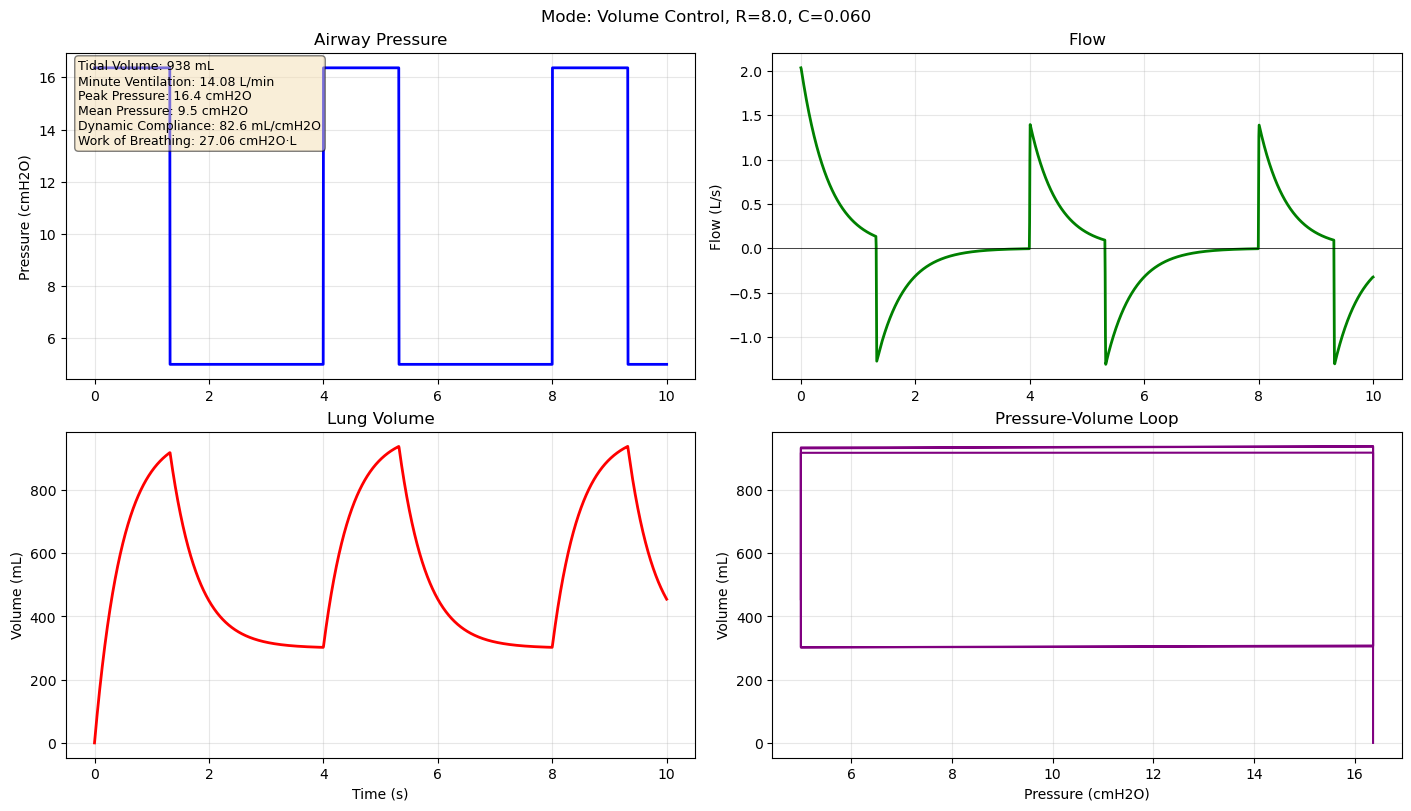


📊 Clinical Metrics:
  Vt_mL: 938.35
  Minute_vent_Lmin: 14.08
  Peak_P_cmH2O: 16.36
  Mean_P_cmH2O: 9.50
  C_dyn_mL_cmH2O: 82.58
  WOB_cmH2O_L: 27.06


In [3]:
# 03_ventilation_modes.ipynb – Volume Control, Pressure Support, SIMV

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display, clear_output

# ============================================================
# Common lung model (single compartment)
# ============================================================

def lung_ode(t, y, R, C, P_aw_func):
    V = y[0]
    P_aw = P_aw_func(t)
    Q = (P_aw - V/C) / R
    if V <= 0 and Q < 0:
        Q = 0
    return [Q]

def simulate_mode(R, C, PEEP, mode, mode_params, duration=10):
    """
    mode_params: dict with keys specific to each mode
    """
    t_eval = np.linspace(0, duration, 2000)
    
    if mode == 'Volume Control':
        Vt = mode_params['Vt']
        rate = mode_params['rate']
        insp_frac = mode_params.get('insp_frac', 0.33)
        insp_time = (60/rate) * insp_frac
        Q_set = Vt / insp_time  # constant flow during inspiration
        def P_aw_func(t):
            period = 60/rate
            t_mod = t % period
            if t_mod < insp_time:
                return PEEP + Q_set * R + Vt/(C)  # Pressure needed to deliver Vt
            else:
                return PEEP
    elif mode == 'Pressure Support':
        # Pressure support: patient triggers, then pressure rises to P_support
        # Simplified: spontaneous effort simulated as sinusoid, if exceeds threshold, apply P_support for a fixed time
        P_support = mode_params['P_support']
        trigger_threshold = mode_params.get('trigger_threshold', 2)  # cmH2O
        support_time = mode_params.get('support_time', 1.0)  # seconds
        
        muscle_pressure_amp = mode_params.get('muscle_amp', 5)
        muscle_freq = mode_params.get('muscle_freq', 0.5)  # Hz
        def P_aw_func(t):
            # Simulate patient muscle pressure
            P_muscle = muscle_pressure_amp * np.sin(2*np.pi*muscle_freq*t)
    
            if P_muscle > trigger_threshold:
                return PEEP + P_support
            else:
                return PEEP
        return P_aw_func
    elif mode == 'SIMV':
        # Synchronized Intermittent Mandatory Ventilation: mandatory breaths at a set rate,
        rate_mandatory = mode_params['rate_mandatory']
        Vt_mandatory = mode_params['Vt_mandatory']
        insp_frac = mode_params.get('insp_frac', 0.33)
        P_support = mode_params.get('P_support', 10)
        trigger_threshold = mode_params.get('trigger_threshold', 2)
        muscle_amp = mode_params.get('muscle_amp', 5)
        muscle_freq = mode_params.get('muscle_freq', 0.5)
        insp_time_mandatory = (60/rate_mandatory) * insp_frac
        Q_set_mandatory = Vt_mandatory / insp_time_mandatory
        def P_aw_func(t):
            # Check for mandatory breath window (around the expected time)
            period = 60/rate_mandatory
            t_mod = t % period
            if t_mod < insp_time_mandatory:
                # mandatory breath
                return PEEP + Q_set_mandatory * R + Vt_mandatory/C
            else:
                # Spontaneous support: check muscle pressure
                P_muscle = muscle_amp * np.sin(2*np.pi*muscle_freq*t)
                if P_muscle > trigger_threshold:
                    return PEEP + P_support
                else:
                    return PEEP
        return P_aw_func
    else:
        raise ValueError('Unknown mode')
    
    # Solve ODE with the generated P_aw_func
    sol = solve_ivp(lung_ode, (0,duration), [0.0], t_eval=t_eval,
                    args=(R, C, P_aw_func), method='RK45', rtol=1e-6)
    t = sol.t
    V = sol.y[0]
    Q = np.gradient(V, t)
    # Recompute P_aw from the ODE solution to ensure consistency
    P_aw = np.zeros_like(t)
    for i, ti in enumerate(t):
        P_aw[i] = P_aw_func(ti)
    return t, V, Q, P_aw

def compute_metrics(t, V, Q, P_aw, PEEP, rate=None):
    V_tidal = np.max(V) - np.min(V)
    minute_vent = V_tidal * (rate if rate else 60/(t[-1]-t[0]))
    peak_P = np.max(P_aw)
    mean_P = np.mean(P_aw)
    C_dyn = V_tidal / (peak_P - PEEP) if (peak_P - PEEP) > 0 else 0
    # Work of breathing (area under PV loop)
    WOB = np.trapz(P_aw, V)  # (cmH2O * L)
    return {
        'Vt_mL': V_tidal * 1000,
        'Minute_vent_Lmin': minute_vent,
        'Peak_P_cmH2O': peak_P,
        'Mean_P_cmH2O': mean_P,
        'C_dyn_mL_cmH2O': C_dyn * 1000,
        'WOB_cmH2O_L': WOB
    }

def plot_results(t, V, Q, P_aw, R, C, mode, mode_params):
    # Determine rate for metrics
    if mode == 'Volume Control':
        rate = mode_params['rate']
    elif mode == 'SIMV':
        rate = mode_params['rate_mandatory']
    else:
        rate = 60/(t[-1]-t[0])  # approximate
    metrics = compute_metrics(t, V, Q, P_aw, mode_params.get('PEEP', 5), rate)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
    ax1, ax2 = axes[0, 0], axes[0, 1]
    ax3, ax4 = axes[1, 0], axes[1, 1]
    
    ax1.plot(t, P_aw, 'b-', lw=2)
    ax1.set_ylabel('Pressure (cmH2O)')
    ax1.set_title('Airway Pressure')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(t, Q, 'g-', lw=2)
    ax2.axhline(0, color='k', lw=0.5)
    ax2.set_ylabel('Flow (L/s)')
    ax2.set_title('Flow')
    ax2.grid(True, alpha=0.3)
    
    ax3.plot(t, V*1000, 'r-', lw=2)
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Volume (mL)')
    ax3.set_title('Lung Volume')
    ax3.grid(True, alpha=0.3)
    
    ax4.plot(P_aw, V*1000, 'purple', lw=1.5)
    ax4.set_xlabel('Pressure (cmH2O)')
    ax4.set_ylabel('Volume (mL)')
    ax4.set_title('Pressure-Volume Loop')
    ax4.grid(True, alpha=0.3)
    
    fig.suptitle(f'Mode: {mode}, R={R:.1f}, C={C:.3f}')
    
    textstr = (f"Tidal Volume: {metrics['Vt_mL']:.0f} mL\n"
               f"Minute Ventilation: {metrics['Minute_vent_Lmin']:.2f} L/min\n"
               f"Peak Pressure: {metrics['Peak_P_cmH2O']:.1f} cmH2O\n"
               f"Mean Pressure: {metrics['Mean_P_cmH2O']:.1f} cmH2O\n"
               f"Dynamic Compliance: {metrics['C_dyn_mL_cmH2O']:.1f} mL/cmH2O\n"
               f"Work of Breathing: {metrics['WOB_cmH2O_L']:.2f} cmH2O·L")
    ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=9,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.show()
    print("\n📊 Clinical Metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.2f}")

# ============================================================
# Interactive widgets for mode selection
# ============================================================

style = {'description_width': 'initial'}
mode_selector = widgets.Dropdown(options=['Volume Control', 'Pressure Support', 'SIMV'], value='Volume Control', description='Mode:')
R_slider = widgets.FloatSlider(value=8, min=2, max=30, step=0.5, description='Resistance (cmH2O/L/s):', style=style)
C_slider = widgets.FloatSlider(value=0.06, min=0.02, max=0.15, step=0.002, description='Compliance (L/cmH2O):', style=style)
PEEP_slider = widgets.FloatSlider(value=5, min=0, max=15, step=1, description='PEEP (cmH2O):', style=style)
duration_slider = widgets.FloatSlider(value=10, min=5, max=30, step=1, description='Duration (s):', style=style)

# Mode-specific sliders (initially for VC)
Vt_slider = widgets.FloatSlider(value=0.5, min=0.2, max=1.0, step=0.01, description='Tidal Volume (L):', style=style)
rate_slider = widgets.IntSlider(value=15, min=8, max=30, step=1, description='Rate (bpm):', style=style)
insp_frac_slider = widgets.FloatSlider(value=0.33, min=0.2, max=0.5, step=0.01, description='I:E ratio (insp fraction):', style=style)
# For pressure support and SIMV
P_support_slider = widgets.FloatSlider(value=10, min=5, max=25, step=0.5, description='Support Pressure (cmH2O):', style=style)
trigger_slider = widgets.FloatSlider(value=2, min=1, max=5, step=0.5, description='Trigger threshold (cmH2O):', style=style)
muscle_amp_slider = widgets.FloatSlider(value=5, min=0, max=15, step=0.5, description='Muscle effort amplitude (cmH2O):', style=style)
muscle_freq_slider = widgets.FloatSlider(value=0.5, min=0.2, max=1.5, step=0.05, description='Muscle effort frequency (Hz):', style=style)
# For SIMV only
rate_mandatory_slider = widgets.IntSlider(value=10, min=5, max=25, step=1, description='Mandatory rate (bpm):', style=style)
Vt_mandatory_slider = widgets.FloatSlider(value=0.5, min=0.2, max=1.0, step=0.01, description='Mandatory Vt (L):', style=style)

# Container for mode-specific UI
mode_ui = widgets.VBox([])

def update_mode_visibility(change):
    mode = mode_selector.value
    children = []
    children.append(widgets.HBox([R_slider, C_slider]))
    children.append(widgets.HBox([PEEP_slider, duration_slider]))
    if mode == 'Volume Control':
        children.append(widgets.HBox([Vt_slider, rate_slider, insp_frac_slider]))
    elif mode == 'Pressure Support':
        children.append(widgets.HBox([P_support_slider, trigger_slider]))
        children.append(widgets.HBox([muscle_amp_slider, muscle_freq_slider]))
    elif mode == 'SIMV':
        children.append(widgets.HBox([rate_mandatory_slider, Vt_mandatory_slider, insp_frac_slider]))
        children.append(widgets.HBox([P_support_slider, trigger_slider]))
        children.append(widgets.HBox([muscle_amp_slider, muscle_freq_slider]))
    mode_ui.children = children

mode_selector.observe(update_mode_visibility, 'value')
update_mode_visibility(None)

def run_simulation(R, C, PEEP, duration, mode, **kwargs):
    clear_output(wait=True)
    mode_params = {'PEEP': PEEP}
    if mode == 'Volume Control':
        mode_params.update({'Vt': kwargs['Vt'], 'rate': kwargs['rate'], 'insp_frac': kwargs['insp_frac']})
    elif mode == 'Pressure Support':
        mode_params.update({'P_support': kwargs['P_support'], 'trigger_threshold': kwargs['trigger'],
                            'muscle_amp': kwargs['muscle_amp'], 'muscle_freq': kwargs['muscle_freq']})
    elif mode == 'SIMV':
        mode_params.update({'rate_mandatory': kwargs['rate_mandatory'], 'Vt_mandatory': kwargs['Vt_mandatory'],
                            'insp_frac': kwargs['insp_frac'], 'P_support': kwargs['P_support'],
                            'trigger_threshold': kwargs['trigger'], 'muscle_amp': kwargs['muscle_amp'],
                            'muscle_freq': kwargs['muscle_freq']})
    else:
        return
    t, V, Q, P_aw = simulate_mode(R, C, PEEP, mode, mode_params, duration)
    plot_results(t, V, Q, P_aw, R, C, mode, mode_params)

# Combine UI and interactive output
ui_top = widgets.VBox([mode_selector, mode_ui])
out = widgets.interactive_output(run_simulation, {
    'R': R_slider, 'C': C_slider, 'PEEP': PEEP_slider, 'duration': duration_slider, 'mode': mode_selector,
    'Vt': Vt_slider, 'rate': rate_slider, 'insp_frac': insp_frac_slider,
    'P_support': P_support_slider, 'trigger': trigger_slider,
    'muscle_amp': muscle_amp_slider, 'muscle_freq': muscle_freq_slider,
    'rate_mandatory': rate_mandatory_slider, 'Vt_mandatory': Vt_mandatory_slider
})

display(ui_top, out)
# Trigger initial simulation
run_simulation(R_slider.value, C_slider.value, PEEP_slider.value, duration_slider.value, mode_selector.value,
               Vt=Vt_slider.value, rate=rate_slider.value, insp_frac=insp_frac_slider.value,
               P_support=P_support_slider.value, trigger=trigger_slider.value,
               muscle_amp=muscle_amp_slider.value, muscle_freq=muscle_freq_slider.value,
               rate_mandatory=rate_mandatory_slider.value, Vt_mandatory=Vt_mandatory_slider.value)
